### Disaster tweet classification project using DistillBert

In this notebook, we would be using the DistillBert architecture to predict on the Disaster tweet dataset from kaggle

In [1]:
# get helper functions
!wget https://raw.githubusercontent.com/Doyinakinloye/Helper_functions/refs/heads/main/Helper_functions.py

--2026-06-15 18:13:50--  https://raw.githubusercontent.com/Doyinakinloye/Helper_functions/refs/heads/main/Helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11537 (11K) [text/plain]
Saving to: ‘Helper_functions.py’

Helper_functions.py 100%[===================>]  11.27K  --.-KB/s    in 0.001s  

2026-06-15 18:13:50 (20.3 MB/s) - ‘Helper_functions.py’ saved [11537/11537]



In [2]:
from Helper_functions import *

### Get a text dataset

In [3]:
# Kaggle introduction to NLP dataset
!wget https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip

--2026-06-15 18:13:54--  https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.43.207, 74.125.142.207, 74.125.195.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.43.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 607343 (593K) [application/zip]
Saving to: ‘nlp_getting_started.zip’

nlp_getting_started 100%[===================>] 593.11K  --.-KB/s    in 0.005s  

2026-06-15 18:13:54 (124 MB/s) - ‘nlp_getting_started.zip’ saved [607343/607343]



In [4]:
# unzip the data
unzip_data("nlp_getting_started.zip")

In [5]:
# split the data into train and test sets
import pandas as pd
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [6]:
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [7]:
# split the train df into training and validation sets
from sklearn.model_selection import train_test_split
train_sentences, val_sentences, train_labels, val_labels = train_test_split(train_df["text"],
                                                                  train_df["target"],
                                                                  test_size=0.1,
                                                                  random_state=42,
                                                                  stratify=train_df["target"])

In [8]:
train_sentences

,text
6867,Trauma can happen anywhere -- school home etc....
5188,@breakingnewslh @bree_mars watch cnn's the sev...
5413,?You should be scared. You should be screaming...
5499,when you are quarantined to a little corner bc...
2308,@AngusMacNeilSNP Every case for Yes has been u...
...,...
1220,Sinking ships burning buildings &amp; Falling ...
424,#Arsonist arrested for setting many fires. WAT...
305,#PBBan (Temporary:300) Russaky89 @'aRmageddon ...
1648,Petition | Heartless owner that whipped horse ...


In [9]:
train_labels.value_counts()

,count
target,
0,3907
1,2944


In [10]:
val_labels.value_counts()

,count
target,
0,435
1,327


In [11]:
# import the necessary libraries
!pip install pip

In [12]:
# Force reinstall transformers and tensorflow to ensure a clean installation
!pip install --force-reinstall transformers tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 

In [13]:
from transformers import DistilBertTokenizerFast

# tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [14]:
# token encodings
train_encodings = tokenizer(train_sentences.tolist(), truncation=True, padding=True)
val_encodings = tokenizer(val_sentences.tolist(), truncation=True, padding=True)

In [15]:
train_encodings[:10]

[Encoding(num_tokens=84, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=84, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=84, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=84, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=84, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=84, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=84, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=84, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=84, attribu

In [16]:
import torch
# Torch dataset wrapper
class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

In [17]:
train_dataset = TweetDataset(train_encodings, train_labels)
val_dataset = TweetDataset(val_encodings, val_labels)

In [18]:
train_dataset[0]

{'input_ids': tensor([  101, 12603,  2064,  4148,  5973,  1011,  1011,  2082,  2188,  4385,
          1012,  1011,  1011,  2012,  2151,  2051,  1012,  4553,  1996,  5925,
          1005,  1055,  1997, 12603,  1998,  2129,  2000,  6687,  1012,  1012,
          1012,  1057,  1035,  8299,  1024,  1013,  1013,  1056,  1012,  2522,
          1013,  4718,  3501,  2620, 22984,  3501,  2100,  2620,  2050,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'labels

In [19]:
from transformers import DistilBertForSequenceClassification

# build model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10,
    learning_rate=2e-5
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [21]:
# compute the accuracy
from sklearn.metrics import accuracy_score
# create a function that computes the models accuracy
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc}

In [22]:
from transformers import Trainer

In [23]:
# Re-instantiate the Trainer for training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [24]:
# Train
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.383728,0.413286,0.820210
2,0.376201,0.376473,0.847769
3,0.311242,0.409260,0.837270


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=645, training_loss=0.4298525009968484, metrics={'train_runtime': 165.0983, 'train_samples_per_second': 124.489, 'train_steps_per_second': 3.907, 'total_flos': 446676963563376.0, 'train_loss': 0.4298525009968484, 'epoch': 3.0})

In [25]:
# Evaluate
results = trainer.evaluate()
print("Accuracy:", results["eval_accuracy"])

Training Loss,Validation Loss,Epoch,Accuracy
0.311242,0.409260,3,0.837270


Accuracy: 0.8372703412073491


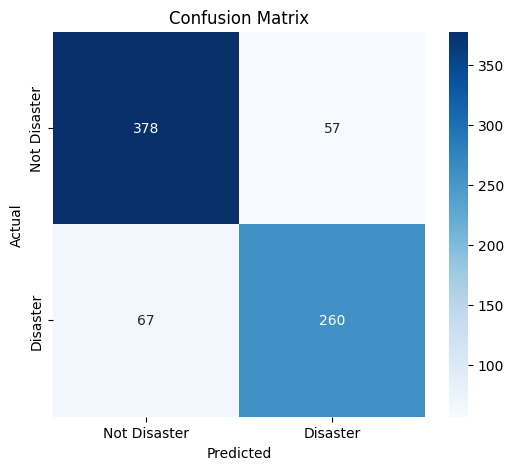

              precision    recall  f1-score   support

Not Disaster       0.85      0.87      0.86       435
    Disaster       0.82      0.80      0.81       327

    accuracy                           0.84       762
   macro avg       0.83      0.83      0.83       762
weighted avg       0.84      0.84      0.84       762



In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot with seaborn
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster', 'Disaster'],
            yticklabels=['Not Disaster', 'Disaster'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 4. Optional: print classification report
print(classification_report(y_true, y_pred, target_names=['Not Disaster','Disaster']))

### Handling Class Imbalance

When one class (e.g., 'no-disaster') has significantly more samples than another (e.g., 'disaster'), a model can become biased and perform poorly on the minority class, even if overall accuracy seems high.

To address this, we can use **class weighting**. This involves assigning a higher penalty (weight) to misclassifications of the minority class during training. PyTorch's `CrossEntropyLoss` function supports a `weight` argument that allows us to specify these custom weights.

We will calculate these weights based on the inverse frequency of each class in your training data.

In [27]:
import torch
from torch.nn import CrossEntropyLoss
import numpy as np

# Calculate class counts from training labels
class_counts = np.bincount(train_labels)

# Calculate inverse frequency weights
weights = torch.tensor(len(train_labels) / (2.0 * class_counts), dtype=torch.float)

print(f"Class counts: {class_counts}")
print(f"Calculated class weights: {weights}")

# Move weights to the appropriate device (e.g., GPU if available)
if torch.cuda.is_available():
    weights = weights.to('cuda')
    print("Moved weights to CUDA.")
else:
    print("CUDA not available, weights remain on CPU.")

# Define the loss function with class weights
loss_fn = CrossEntropyLoss(weight=weights)

Class counts: [3907 2944]
Calculated class weights: tensor([0.8768, 1.1636])
Moved weights to CUDA.


Now, let's define a custom `Trainer` class, `WeightedTrainer`, that overrides the `compute_loss` method to use our `loss_fn` with class weights. This will ensure that the model pays more attention to the minority class during training.

In [28]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Use the pre-defined weighted loss function
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

With the `WeightedTrainer` defined, we need to re-instantiate our `trainer` object using this custom class instead of the default `Trainer`. This will apply the class weighting during the training process.

In [29]:
# Re-instantiate the Trainer for training, now using the WeightedTrainer
trainer_1 = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [30]:
# retrain our trainer
trainer_1.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.214141,0.484099,0.812336
2,0.213731,0.456852,0.846457
3,0.289703,0.584103,0.807087


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=645, training_loss=0.2224106049352838, metrics={'train_runtime': 167.1549, 'train_samples_per_second': 122.958, 'train_steps_per_second': 3.859, 'total_flos': 446676963563376.0, 'train_loss': 0.2224106049352838, 'epoch': 3.0})

In [31]:
# Evaluate
results = trainer_1.evaluate()
print("Accuracy:", results["eval_accuracy"])

Training Loss,Validation Loss,Epoch,Accuracy
0.289703,0.584103,3,0.807087


Accuracy: 0.8070866141732284


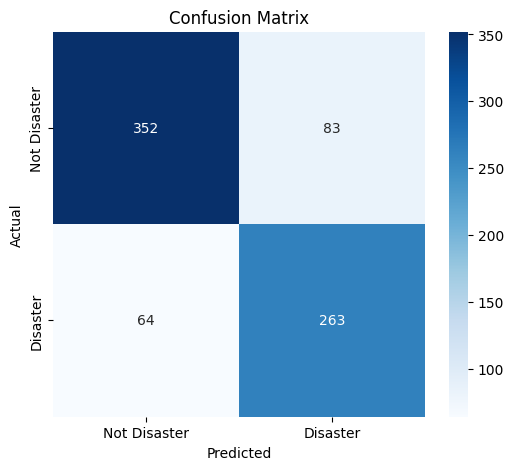

              precision    recall  f1-score   support

Not Disaster       0.85      0.81      0.83       435
    Disaster       0.76      0.80      0.78       327

    accuracy                           0.81       762
   macro avg       0.80      0.81      0.80       762
weighted avg       0.81      0.81      0.81       762



In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions
predictions = trainer_1.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot with seaborn
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster', 'Disaster'],
            yticklabels=['Not Disaster', 'Disaster'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 4. Optional: print classification report
print(classification_report(y_true, y_pred, target_names=['Not Disaster','Disaster']))

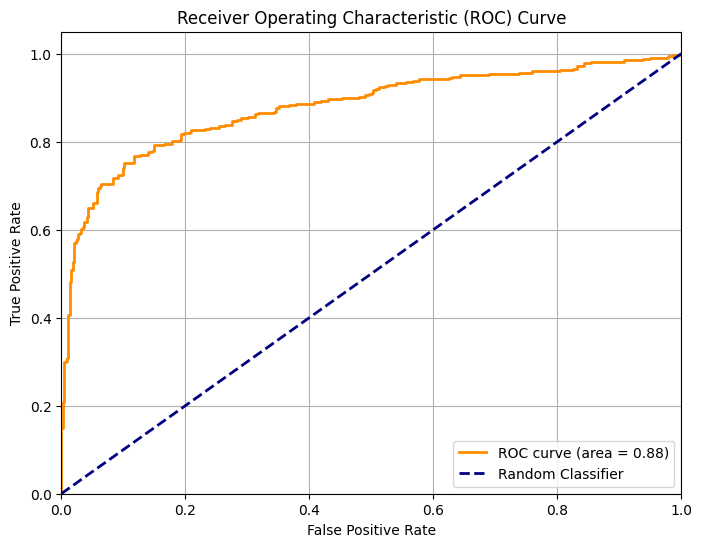

AUC Score: 0.8791


In [33]:
# plot auc and roc curve
from sklearn.metrics import accuracy_score, precision_recall_curve, auc, roc_curve
import matplotlib.pyplot as plt
import torch
import numpy as np

# Get predictions from the trainer (already done in the previous cell for confusion matrix)
# predictions = trainer.predict(val_dataset)
y_true = predictions.label_ids

# Convert logits to probabilities for the positive class (class 1)
# trainer.predict().predictions contains the logits
logits = predictions.predictions

# Apply softmax to get probabilities. For binary classification, we care about the probability of the positive class.
# Assuming the second column (index 1) corresponds to the positive class.
probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_true, probabilities)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")


In [37]:
# Predict on custom data

import torch
import numpy as np

# 1. Define your custom text data
custom_texts = [
    "There's a massive wildfire spreading rapidly, evacuating homes!",
    "Just saw a beautiful sunset, what a lovely day.",
    "Emergency services are responding to a major earthquake in the city center.",
    "Having a great time at the beach with friends.",
    "Breaking news: Flooding reported in several coastal areas due to heavy rainfall.",
    "GodLogic was totally destroyed during yesterday's debate"
]

# 2. Tokenize the custom texts using the same tokenizer used for training
custom_encodings = tokenizer(custom_texts, truncation=True, padding=True)

# 3. Create a custom dataset for prediction. It doesn't need labels.
class CustomPredictionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __len__(self):
        return len(self.encodings['input_ids'])
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        return item

custom_dataset = CustomPredictionDataset(custom_encodings)

# 4. Use the trained trainer (trainer_1) to make predictions
custom_predictions_output = trainer.predict(custom_dataset)

# 5. Process the predictions
# The raw predictions are logits, convert them to class labels.
# Assuming the second column (index 1) is the positive class (Disaster)
logits = custom_predictions_output.predictions
custom_predicted_labels = np.argmax(logits, axis=1)

# Apply softmax to get probabilities for both classes, then take the probability of the positive class.
custom_probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# 6. Display the results
print("--- Custom Data Predictions ---")
for i, text in enumerate(custom_texts):
    label = "Disaster" if custom_predicted_labels[i] == 1 else "Not Disaster"
    prob = custom_probabilities[i]
    print(f"Text: '{text}'")
    print(f"Predicted Label: {label} (Probability of Disaster: {prob:.4f})")
    print("\n")


--- Custom Data Predictions ---
Text: 'There's a massive wildfire spreading rapidly, evacuating homes!'
Predicted Label: Disaster (Probability of Disaster: 0.9962)


Text: 'Just saw a beautiful sunset, what a lovely day.'
Predicted Label: Not Disaster (Probability of Disaster: 0.2742)


Text: 'Emergency services are responding to a major earthquake in the city center.'
Predicted Label: Disaster (Probability of Disaster: 0.9972)


Text: 'Having a great time at the beach with friends.'
Predicted Label: Not Disaster (Probability of Disaster: 0.1145)


Text: 'Breaking news: Flooding reported in several coastal areas due to heavy rainfall.'
Predicted Label: Disaster (Probability of Disaster: 0.9964)


Text: 'GodLogic was totally destroyed during yesterday's debate'
Predicted Label: Not Disaster (Probability of Disaster: 0.0394)


